# Phase 2B: D1 candidate domain and D2 background samples

This notebook presents the strict D1 domain, the 5 km grid decision, and the D2 sampling design. All figures read only the final workbook.


In [1]:
import pandas as pd
from pathlib import Path
import sys
for _candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (_candidate / 'outputs' / 'Data center' / 'TN').is_dir():
        ROOT = _candidate
        break
else:
    raise FileNotFoundError('Run from the project or a child directory.')
_support = ROOT / 'TN' / 'model' / 'notebook_support'
if str(_support) not in sys.path:
    sys.path.insert(0, str(_support))
from tn_common import PALETTE, horizontal_bars, paired_bars
from phase2_io import load_phase2_workbook
here = Path.cwd().resolve()
tables = load_phase2_workbook(ROOT)
path = tables.path; sheets = tables.sheets
domain = sheets['Domain_Cells']; presence = sheets['Presence_Sites']; background = sheets['Background_Samples']
audit = sheets['Background_Sampling_Audit']; scale = sheets['Grid_Scale_Diagnostics']
quality = sheets['Data_Quality'].set_index('metric')['value']


In [2]:
assert len(domain) == 4502
assert domain['d1_status'].value_counts().to_dict() == {'eligible': 4391, 'excluded': 110, 'unresolved': 1}
assert domain['d1_feasible'].eq(domain['d1_status'].eq('eligible')).all()
resolved = domain['d1_status'].ne('unresolved')
assert domain.loc[resolved, 'military_land_frac'].ge(0).all()
assert domain.loc[resolved, 'hard_exclusion_union_frac'].between(0, 1).all()
assert quality['primary_grid_resolution_km'] == 5
assert scale.loc[scale['grid_resolution_km'].eq(5), 'primary_presence_in_d1'].iat[0] == 60
print('D1 strict-domain validation passed')


D1 strict-domain validation passed


## D1 hard-constraint composition

The rows below overlap: the hard-exclusion union is therefore not the sum of individual constraints.


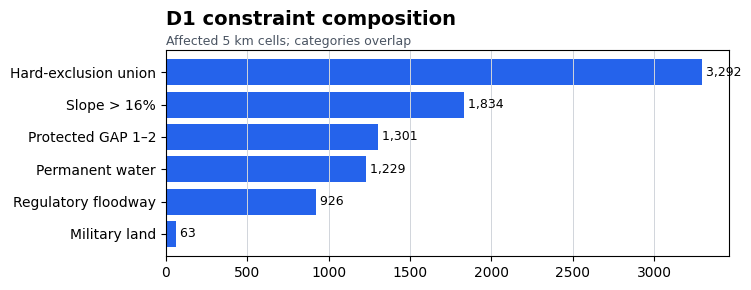

In [3]:
constraint_cols = {
    'Hard-exclusion union': 'hard_exclusion_union_frac',
    'Slope > 16%': 'slope_excluded_frac',
    'Protected GAP 1–2': 'protected_gap12_frac',
    'Permanent water': 'permanent_open_water_frac',
    'Regulatory floodway': 'regulatory_floodway_frac',
    'Military land': 'military_land_frac',
}
resolved_domain = domain.loc[domain['d1_status'].ne('unresolved')]
affected = [int(resolved_domain[col].gt(0).sum()) for col in constraint_cols.values()]
horizontal_bars('D1 constraint composition', list(constraint_cols), affected, note='Affected 5 km cells; categories overlap')


## Grid-scale comparison

The 5 km primary grid is the selected resolution: it retains all 60 primary presences while preserving substantially more spatial detail than 7 km.


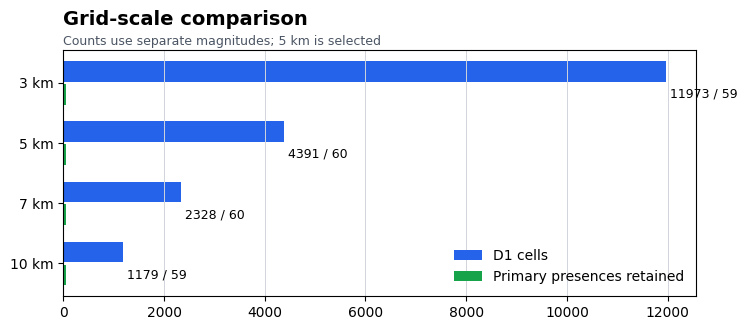

In [4]:
labels = [f"{int(v)} km" for v in scale['grid_resolution_km']]
paired_bars('Grid-scale comparison', labels, scale['d1_cells'].tolist(), scale['primary_presence_in_d1'].tolist(), 'D1 cells', 'Primary presences retained', 'Counts use separate magnitudes; 5 km is selected')


In [5]:
expected = {'primary': 600, 'weighted': 740, 'strict': 730}
counts = background.groupby(['scenario', 'draw']).size()
for scenario, n in expected.items():
    assert set(counts.loc[scenario]) == {n}
assert not background.duplicated(['scenario', 'draw', 'cell_id']).any()
assert not background['cell_id'].isin(set(presence['cell_id'])).any()
ratio10 = audit.loc[audit['ratio_target'].eq(10)]
assert ratio10['quota_status'].eq('met').all()
ratio20 = audit.loc[audit['ratio_target'].eq(20)]
assert ratio20['quota_status'].eq('census_shortfall').sum() == 120
assert audit['quota_status'].eq('zero_eligible_conflict').sum() == 0
print('D2 sampling validation passed')


D2 sampling validation passed


## D2 ratio sensitivity

Each ratio has 360 scenario × draw × stratum quotas. At 20:1, 120 quotas require census sampling; 10:1 has no shortfalls.


In [6]:
ratio_outcomes = audit.groupby(['ratio_target', 'quota_status']).size().unstack(fill_value=0)
print(ratio_outcomes)
# The rendered Matplotlib figure above communicates the same audit: 5:1 and 10:1 meet every quota; 20:1 triggers capped census strata.


quota_status  census_shortfall  met
ratio_target                       
5                            0  360
10                           0  360
20                         120  240


## D2 stratified composition

The primary scenario’s first draw keeps the observed spatial composition at the intended 10:1 ratio in each of six region × urban-context strata.


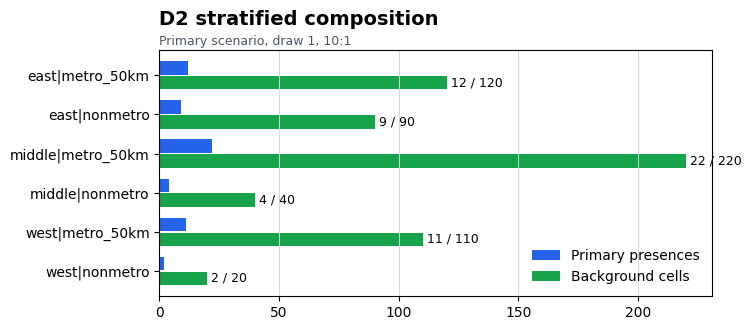

,primary_presence,background_cells
sampling_stratum,,
east|metro_50km,12,120
east|nonmetro,9,90
middle|metro_50km,22,220
middle|nonmetro,4,40
west|metro_50km,11,110
west|nonmetro,2,20


In [7]:
primary_presence = presence.loc[presence['primary_weight'].gt(0)].groupby('sampling_stratum').size()
primary_background = background.loc[(background['scenario'].eq('primary')) & (background['ratio_target'].eq(10)) & (background['draw'].eq(1))].groupby('sampling_stratum').size()
composition = pd.concat([primary_presence.rename('primary_presence'), primary_background.rename('background_cells')], axis=1).fillna(0).astype(int)
paired_bars('D2 stratified composition', composition.index.tolist(), composition['primary_presence'].tolist(), composition['background_cells'].tolist(), 'Primary presences', 'Background cells', 'Primary scenario, draw 1, 10:1')
display(composition)


## Phase 2 closeout count scope

The 5 km scale diagnostic counts resolved D0 cells. `Domain_Cells` retains one additional unresolved boundary-mismatch cell for audit, but it is not eligible or sampled.


In [8]:
assert 'd0_count_scope' in scale.columns
scope_5km = scale.loc[scale['grid_resolution_km'].eq(5), 'd0_count_scope'].iat[0]
assert '4,501 resolved cells' in scope_5km
assert 'one additional D0 cell is unresolved' in scope_5km
assert domain['d1_status'].eq('unresolved').sum() == 1
assert domain['d1_feasible'].eq(False).loc[domain['d1_status'].eq('unresolved')].all()
print('Phase 2 grid-count scope validation passed')


Phase 2 grid-count scope validation passed
